# Mini Projeto MNIST

## Data Understanding

### Developed by:
- António Cruz - **Student 140129**
- Ricardo Kayseller - **Student 95813**

# 0. Libraries

In [1]:
# Basic Libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# TorchVision Libraries
import torch
from torchvision import transforms, datasets
from torchvision.datasets import MNIST
import torch.nn.functional as F


import textwrap, importlib, sys
from mnist_eda_toolkit import MNISTEDA, train_test_drift, find_near_duplicates
import glob

# Import MNIST Data
#from keras.datasets import mnist

In [2]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

# 1. Objective and Context
The goal of this notebook is to perform a structured *Data Understanding* process for the MNIST dataset, which will serve as the basis for the subsequent hyperparameter experiments in neural networks. 
We aim to understand the dataset's composition, statistical properties, and potential biases, so as to make informed preprocessing and modeling decisions.


# 2. Dataset Overview

## 2.1 Dataset loading and shapes

In [3]:
# Get the tensors (0–255, uint8)
train_set = datasets.MNIST(root="./data", train=True,  download=True, transform=None)
test_set  = datasets.MNIST(root="./data", train=False, download=True, transform=None)

# Access data and labels (PyTorch tensors)
X_train, y_train = train_set.data, train_set.targets      
X_test,  y_test  = test_set.data,  test_set.targets      


In [4]:
# Show X_train shape
X_train.shape

torch.Size([60000, 28, 28])

In [5]:
# Show X_test shape
X_test.shape

torch.Size([10000, 28, 28])

## 2.2 Sample visualization and label check

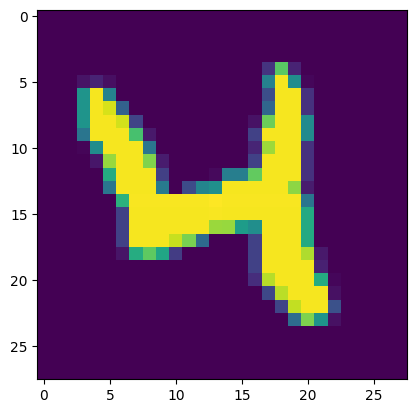

In [6]:
# Show image with indice 20
plt.imshow(X_train[20])

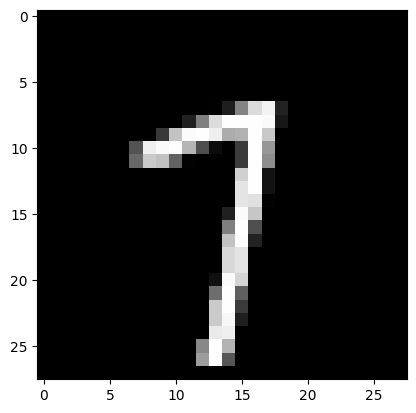

In [7]:
# show image with indice 42 in Grey
plt.imshow(X_train[42], cmap='Greys_r')

In [8]:
# print first 1o labels from y_train
print(f"First 10 labels (y_train): {y_train[:10]}")

# print first 10 feature vectors from X_train
print(f"First 10 feature vectors (X_train):\n{X_train[:10]}")

First 10 labels (y_train): tensor([5, 0, 4, 1, 9, 2, 1, 3, 1, 4])
First 10 feature vectors (X_train):
tensor([[[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        ...,

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0

## 2.3 Train/Test class balance

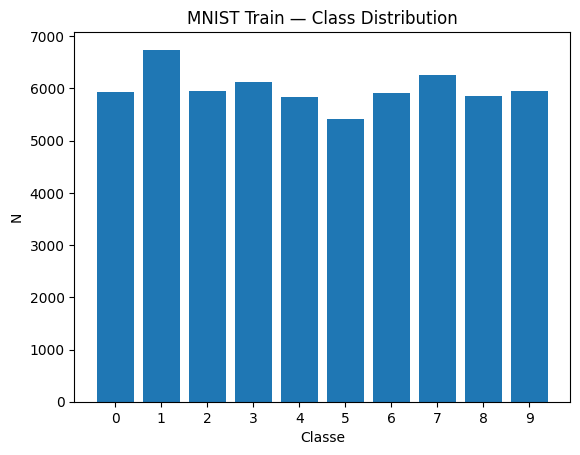

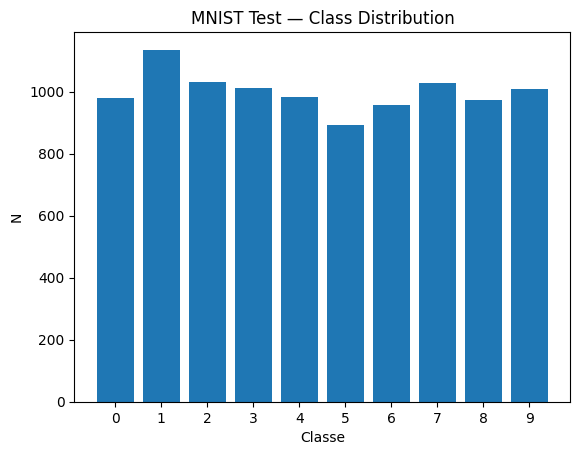

In [9]:
def plot_class_counts(y, title):
    vals, counts = np.unique(y.numpy(), return_counts=True)
    plt.figure()
    plt.bar(vals, counts)
    plt.xticks(vals)
    plt.title(title)
    plt.xlabel("Classe"); plt.ylabel("N")
    plt.show()

plot_class_counts(y_train, "MNIST Train — Class Distribution")
plot_class_counts(y_test,  "MNIST Test — Class Distribution")

**MNIST — class distribution (train & test)**  
- Both splits are **nearly balanced** across digits.  
- **Train:** slight over-representation of **1** and **7**; **5** is the lowest.  
- **Test:** mirrors train → **no class-shift** between splits.  
- **Implications:** accuracy is an appropriate primary metric, but report **per-class accuracy/F1** to catch mild asymmetries.  



## 2.4 Drift between training and test sets

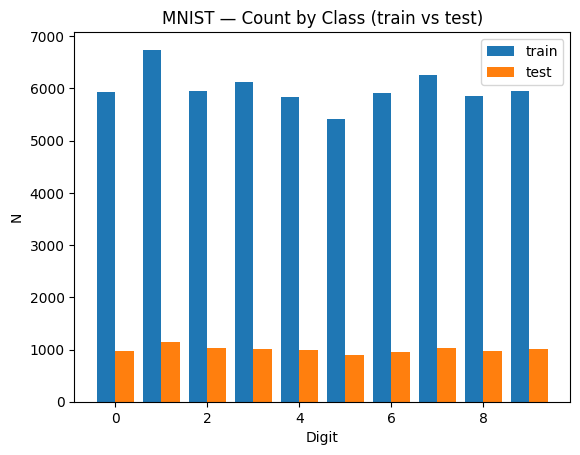

In [42]:
ct = torch.bincount(y_train, minlength=10).numpy()
cs = torch.bincount(y_test,  minlength=10).numpy()
x = np.arange(10); w = 0.4
plt.bar(x-w/2, ct, width=w, label="train")
plt.bar(x+w/2, cs, width=w, label="test")
plt.title("MNIST — Count by Class (train vs test)")
plt.xlabel("Digit")
plt.ylabel("N")
plt.legend()
plt.show()


**Observations — class counts (train vs test)**

- Class frequencies are **fairly balanced** across both splits.
- MNIST is roughly balanced per class in both splits (train ≈ 5.4k–6.8k per class; test ≈ 980–1.1k). 
- Small deviations exist (e.g., digit **1** slightly higher in train; digit **5** slightly lower), but **no material imbalance** is present.
- Train and Test are well ditributed across classes.



# 3. Statistical Characterization of Pixels

## 3.1 Global pixel statistics (train vs test)

In [11]:
# function to pixel stats
def stats_uint8(x):
    return{
        'min': int(x.min()),
        'max': int(x.max()),
        'mean': float(x.float().mean()),
        'std': float(x.float().std())    
    }

print('Train pixel stats:', stats_uint8(X_train))
print('Test pixel stats:', stats_uint8(X_test))

Train pixel stats: {'min': 0, 'max': 255, 'mean': 33.31842041015625, 'std': 78.56748962402344}
Test pixel stats: {'min': 0, 'max': 255, 'mean': 33.791221618652344, 'std': 79.17247009277344}


## 3.2 Sparsity and saturation

In [12]:
def stats_uint8(x):
    x = x.float()
    return {
        "min": int(x.min()), "max": int(x.max()),
        "mean": float(x.mean()), "std": float(x.std()),
        "pct_zero": float((x==0).float().mean()*100),
        "pct_sat":  float((x>=250).float().mean()*100)
    }

print("Train:", stats_uint8(X_train))
print("Test :", stats_uint8(X_test))



Train: {'min': 0, 'max': 255, 'mean': 33.31842041015625, 'std': 78.56748962402344, 'pct_zero': 80.87976837158203, 'pct_sat': 7.356081962585449}
Test : {'min': 0, 'max': 255, 'mean': 33.791221618652344, 'std': 79.17247009277344, 'pct_zero': 80.7242431640625, 'pct_sat': 7.573647975921631}


**MNIST — pixel sparsity & saturation (train vs test)**
- ~**81%** of pixels are **0** → images are highly sparse (black background dominates).
- ~**7.4%** of pixels are **≥250** → bright strokes, limited but consistent saturation.
- Mean/std match canonical MNIST; train ≈ test on all stats → **no distribution shift**.
- **Implications:** keep normalization `T.Normalize((0.1307,), (0.3081,))`; expect saturating activations (sigmoid/tanh) to be sensitive to LR; ReLU-like activations are naturally robust here.<


## Intensity Histograms

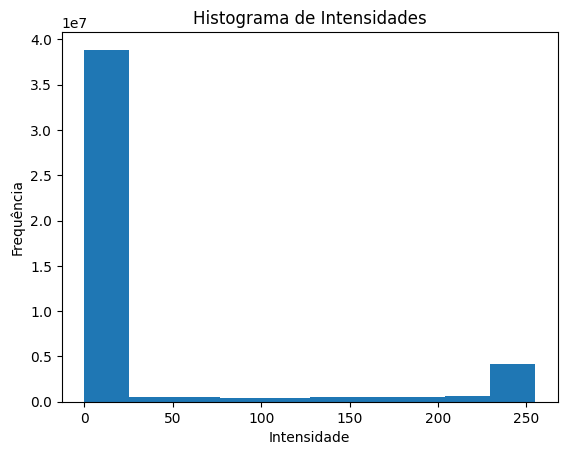

In [13]:
plt.figure()
plt.hist(X_train.flatten().numpy(), bins=10)
plt.title('Histograma de Intensidades')
plt.xlabel('Intensidade')
plt.ylabel('Frequência')
plt.show()

**MNIST — intensity histogram (train)**
- Strong skew toward **0** → background dominates (≈80% pixels at 0).
- Small peak/tail near **255** → bright, saturated strokes (≈7%).
- Implications: normalize (e.g., `T.Normalize((0.1307,), (0.3081,))`); ReLU-like activations handle sparsity well, while sigmoid/tanh can saturate without careful LR.


# 4. Spatial and Morphological Structure

## 4.1 Average image per digit (0–9)

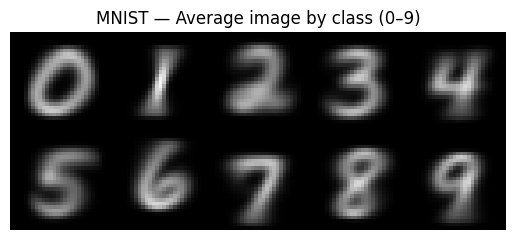

In [14]:
means = [X_train[y_train==k].float().mean(0) for k in range(10)]  # [28,28]
row1 = torch.cat(means[:5], dim=1); row2 = torch.cat(means[5:], dim=1)
mosaic = torch.cat([row1, row2], dim=0).numpy()

plt.figure()
plt.imshow(mosaic, cmap="gray", vmin=0, vmax=255)
plt.title("MNIST — Average image by class (0–9)")
plt.axis("off"); plt.show()



**MNIST — class-wise mean images (quick read)**
- Each tile = pixel-wise average for that digit → brightness shows consistent strokes; blur = variability.
- Sharp: **0/1/7** (low variance). Blurry: **2/3/5/8** (high variance). Likely confusion: **4 ↔ 9**.
- Implication: expect higher accuracy on 0/1/7; add light augmentation (±2 px shift, ±10° rotation) to improve robustness on variable classes.


# 4.2 Variance Map

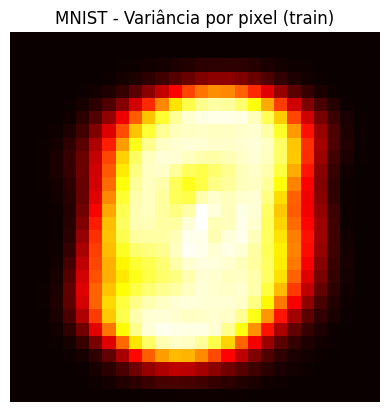

In [15]:
var_img = X_train.float().var(dim=0, correction=0)
plt.figure()
plt.imshow(var_img.numpy(), cmap='hot')
plt.title('MNIST - Variância por pixel (train)')
plt.axis('off')
plt.show()

**MNIST — pixel-wise variance (train)**
- Bright areas = **high variance** → where strokes vary across samples (informative pixels).
- Dark borders = **low variance** → background (mostly zeros).
- Variance concentrated around the **central digit region** with slight asymmetry → small shifts/rotations are common.
- Implications: features should focus on the central area; light augmentation (±2 px shift, ±10° rotation) can improve robustness.


## 4.3 Centroid of the stroke

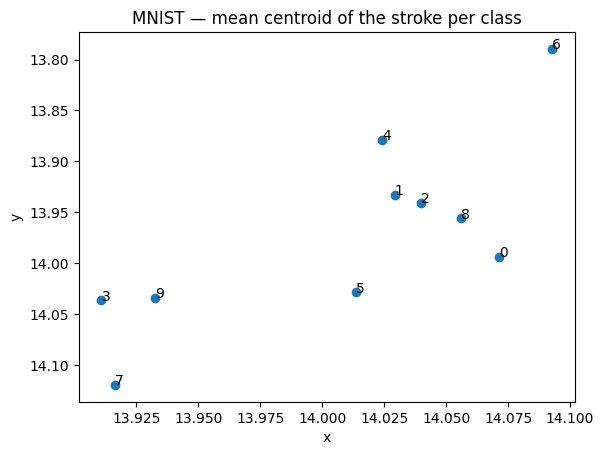

In [16]:
##Centroid of the stroke
rows = torch.arange(28).view(28,1).float()
cols = torch.arange(28).view(1,28).float()

cx, cy = [], []
for k in range(10):
    imgs = X_train[y_train==k].float()
    m = (imgs > 0).float()
    s = m.sum(dim=(1,2)).clamp_min(1.0)
    ry = (m * rows).sum(dim=(1,2)) / s                    # y (linha)
    rx = (m * cols).sum(dim=(1,2)) / s                    # x (coluna)
    cx.append(rx.mean().item()); cy.append(ry.mean().item())

plt.scatter(cx, cy)
for k,(x,y) in enumerate(zip(cx,cy)):
    plt.annotate(str(k), (x,y))
plt.gca().invert_yaxis()
plt.title("MNIST — mean centroid of the stroke per class")
plt.xlabel("x") 
plt.ylabel("y")
plt.show()

**MNIST — mean centroid of the stroke (per class)**
- All class centroids cluster near **(14, 14)** → digits are **well centered**; spread is small (~±0.2 px).
- Slight systematic shifts: e.g., **6** a bit top-right; **7/3/9** slightly left/up; others near center.
- **Implications:** MLP should cope without special alignment; use **light shift augmentation** (±2 px) at most. No need for heavy recentering/padding.


## 4.4 Morphological symmetry and centering

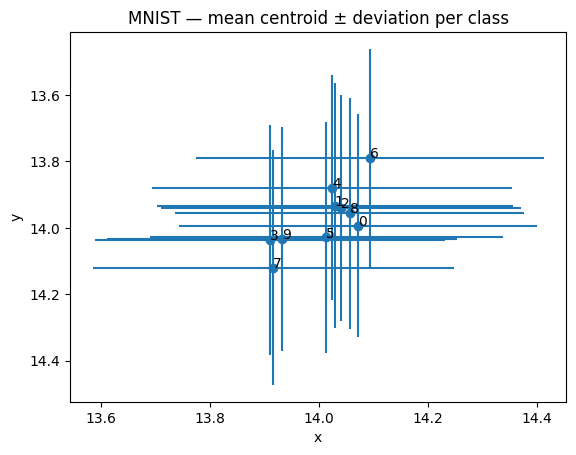

In [17]:
rows = torch.arange(28).view(28,1).float()
cols = torch.arange(28).view(1,28).float()
cx, cy, sx, sy = [], [], [], []
for k in range(10):
    imgs = (X_train[y_train==k] > 0).float()
    s = imgs.sum(dim=(1,2)).clamp_min(1.0)
    ry = (imgs*rows).sum(dim=(1,2)) / s
    rx = (imgs*cols).sum(dim=(1,2)) / s
    cx.append(rx.mean().item()); cy.append(ry.mean().item())
    sx.append(rx.std().item());  sy.append(ry.std().item())

plt.figure()
plt.errorbar(cx, cy, xerr=sx, yerr=sy, fmt='o')
for k,(x,y) in enumerate(zip(cx,cy)):
    plt.annotate(str(k),(x,y))
plt.gca().invert_yaxis()
plt.title("MNIST — mean centroid ± deviation per class")
plt.xlabel("x"); plt.ylabel("y"); plt.show()


**MNIST — mean centroid ± std per class (error bars)**  
- All class centroids cluster near **(14,14)** with **very small (<1 px)** spread in x and y.  
- Some classes show slightly larger vertical spread (e.g., curly digits like 6/5/8), but differences are minor.  
- **Implication:** digits are well centered; an MLP should cope without special alignment. If desired, use only **light shift/rotation augmentation** (±2 px, ±10°) for extra robustness.


## 4.5 Density of Centers of Mass

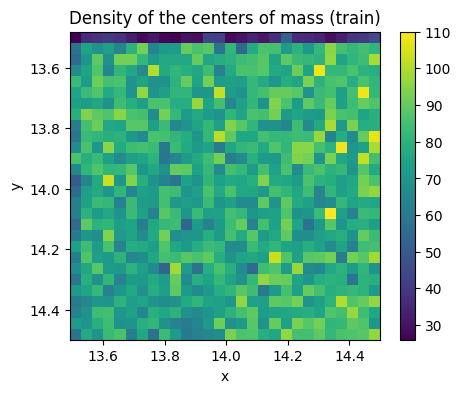

   mean_x  mean_y  std_x  std_y
0  14.014  14.001  0.292  0.291
1  14.021  13.963  0.304  0.292
2  13.999  14.006  0.287  0.290
3  14.009  13.995  0.289  0.290
4  14.004  14.000  0.291  0.290
5  14.004  14.001  0.288  0.288
6  14.001  14.000  0.288  0.283
7  14.007  14.005  0.291  0.289
8  14.008  14.000  0.289  0.288
9  14.000  13.994  0.287  0.288


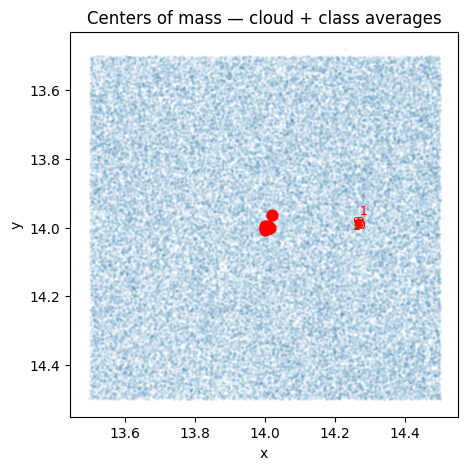

In [18]:
X = x_train if 'x_train' in globals() else X_train
Y = y_train

def centers_of_mass(X, Y):
    X = X.float()
    if X.max() > 1.5:     
        X = X / 255.0
    N, H, W = X.shape
    rows = torch.arange(H).view(H, 1).to(X.device)  # y coordinates
    cols = torch.arange(W).view(1, W).to(X.device)  # x coordinates
    mass = X.sum(dim=(1, 2)).clamp_min(1e-6)        # avoids division by zero
    cy = (X * rows).sum(dim=(1, 2)) / mass          # ȳ
    cx = (X * cols).sum(dim=(1, 2)) / mass          # x̄
    C = torch.stack([cx, cy], dim=1).cpu().numpy()  # [N, 2]
    return C, Y.cpu().numpy()

C, Ynp = centers_of_mass(X, Y)  # C[:,0]=x, C[:,1]=y

# density of the centers (all digits)
plt.figure(figsize=(5,4))
plt.hist2d(C[:,0], C[:,1], bins=[28, 28])
plt.gca().invert_yaxis()
plt.title("Density of the centers of mass (train)")
plt.xlabel("x"); plt.ylabel("y"); plt.colorbar(); plt.show()

# mean by class + dispersion (std)
means, stds = [], []
for k in range(10):
    pts = C[Ynp==k]
    means.append(pts.mean(axis=0))
    stds.append(pts.std(axis=0))
means, stds = np.stack(means), np.stack(stds)

# average per class + dispersion (std)
import pandas as pd
df_center = pd.DataFrame(
    np.c_[means, stds],
    columns=["mean_x","mean_y","std_x","std_y"],
    index=[str(k) for k in range(10)]
).round(3)
print(df_center)

# scatter: all centers (transparent) + class averages
plt.figure(figsize=(5,5))
plt.scatter(C[:,0], C[:,1], s=2, alpha=0.05)
plt.scatter(means[:,0], means[:,1], s=60, c="red")
for k,(mx,my) in enumerate(means):
    plt.text(mx+0.25, my, str(k), color="red", fontsize=9)
plt.gca().invert_yaxis()
plt.title("Centers of mass — cloud + class averages")
plt.xlabel("x"); plt.ylabel("y"); plt.show()


### Centroid alignment (train): density, per-class means, and dispersion


- The **mean centroid per class** is essentially at the image center: ≈ **(14.00, 14.00) px** for all digits, with tiny shifts (|Δ| < **0.03 px**).  
- **Dispersion is very small** (std ≈ **0.28–0.30 px** on x and y), meaning digits are **tightly centered** across the dataset.  
- The density heatmap confirms a **strong concentration near the center**; minor biases (e.g., digit *1* slightly up/right) are **negligible** at this scale.  

**Implications**
- MNIST is **well aligned**; no need for heavy centering/translation preprocessing.  
- Light augmentations (±1–2 px translations, small rotations) may still be applied to enhance robustness without disrupting the dataset’s natural spatial consistency.


## 4.6 Pixel information – Mutual Information with label

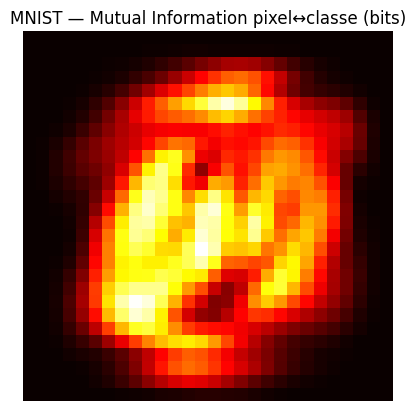

In [19]:
# X = 1 se pixel > 0; MI(X;Y) = H(X) - sum_k P(Y=k) H(X|Y=k)
m = (X_train > 0).float()                       # [N,28,28]
N = m.size(0)
p = m.mean(dim=0)                               # P(X=1)
def Hb(q):                                      # entropia binária (bits)
    eps = 1e-9
    return -(q*torch.log2(q+eps) + (1-q)*torch.log2(1-q+eps))

H = Hb(p)
Hcond = 0.0
for k in range(10):
    mk = m[y_train==k]
    wk = mk.size(0)/N
    Hcond += wk * Hb(mk.mean(dim=0))
MI = (H - Hcond).numpy()                        # [28,28]

plt.figure()
plt.imshow(MI, cmap="hot")
plt.title("MNIST — Mutual Information pixel↔classe (bits)")
plt.axis("off")
plt.show()


**MNIST — Mutual Information map (pixel ↔ class)**  
- Each pixel’s MI with the label (in **bits**): bright = **more discriminative**, dark = **uninformative**.  
- Borders are near-zero (background); the central strokes carry almost all class information.  
- High-MI zones align with distinctive parts (e.g., top-right bar helpful to distinguish **4/7/9**, lower loops for **0/6/8**).  
- Note: we binarized pixels (>0). Using intensity bins would change magnitudes but the pattern stays the same.  
- **Implication:** features should emphasize the central region; light shift/rotation augmentation helps because informative areas are compact and sensitive to misalignment.



## 4.7 Variance per Pixel (Training) and Variance per Class

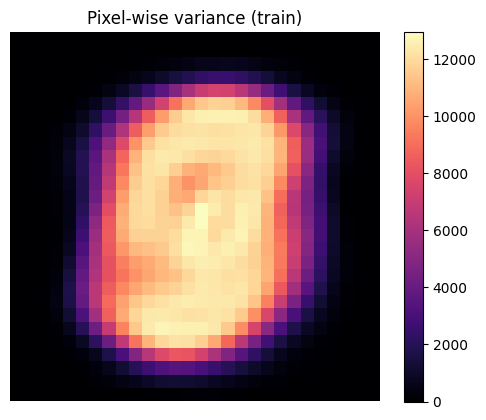

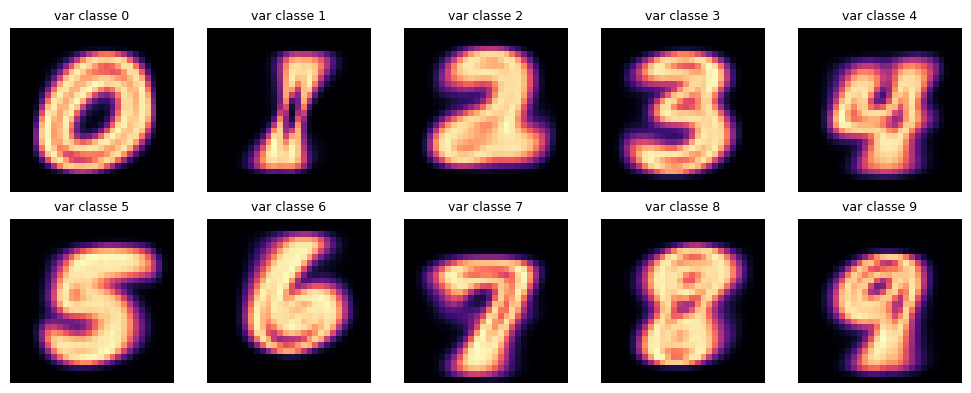

In [20]:
# use x_train, y_train (torch.Tensors) with shape [N, 28, 28]
X = x_train if 'x_train' in globals() else X_train  

# converts to float and calculates variance per pixel in training
Xf = X.float()
var_map = Xf.var(dim=0)              # [28, 28]

import matplotlib.pyplot as plt
plt.figure()
plt.imshow(var_map.numpy(), cmap="magma")
plt.title("Pixel-wise variance (train)")
plt.colorbar(); plt.axis("off"); plt.show()

# (opcional) variância por classe
import torch
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for k, ax in enumerate(axes.ravel()):
    var_k = Xf[(y_train==k)].var(dim=0)
    ax.imshow(var_k.numpy(), cmap="magma")
    ax.set_title(f"var classe {k}", fontsize=9)
    ax.axis("off")
plt.tight_layout(); plt.show()


**Observations**

- The **highest variance** appears around the central vertical and diagonal zones, corresponding to regions where strokes vary most between samples (loops, curves, and crossings).  
- The **edges and corners** show almost zero variance, as they remain consistently blank across all digits.  
- Class-specific maps reveal that digits such as **2, 3, 5, 8, and 9** exhibit broader high-variance zones, confirming their greater **intra-class diversity**.  
- In contrast, digits **1 and 0** display lower variance, reflecting their simpler and more uniform shapes.  

**Implication:**  
Digits with greater structural variability are likely to generate more prediction confusion and benefit from **augmentation techniques** (e.g., small rotations or elastic distortions) to enhance robustness.

# 5. Class-Level Characteristics

# 5.1 Ink Coverage by Class

{0: 24.49, 1: 10.95, 2: 21.53, 3: 20.83, 4: 18.09, 5: 19.43, 6: 20.02, 7: 16.76, 8: 22.11, 9: 18.24}


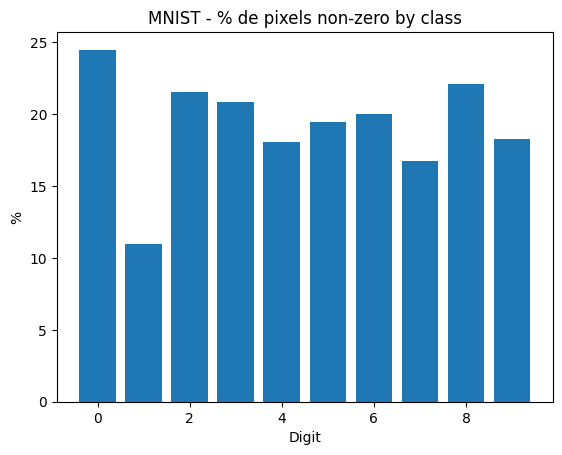

In [21]:
ink = [(X_train[y_train==k] > 0).float().mean().item()*100 for k in range(10)]
print({k: round(v,2) for k,v in enumerate(ink)})
plt.figure()
plt.bar(range(10), ink)
plt.title('MNIST - % de pixels non-zero by class')
plt.xlabel('Digit')
plt.ylabel('%')
plt.show()

**MNIST — % of non-zero pixels per class (“ink coverage”)**
- Highest coverage: **0** and **8** (closed loops → more white area). Lowest: **1** (thin stroke), then **7/4**.
- Classes with **less ink** carry less signal → more sensitive to noise/Dropout; classes with **more ink** tend to be more robust.
- Mild per-class imbalance in coverage suggests checking **per-class accuracy/F1** in addition to overall accuracy.
- Note: threshold was `> 0` (binary). Using a small cutoff (e.g., `> 30` in [0–255]) yields similar ordering and avoids counting very faint pixels.


## 5.2 Stroke thickness (mean ± sd)

   classe  ink_mass_mean  ink_mass_std  onpx_mean  onpx_std
0       0         0.1734        0.0421     0.1980    0.0430
1       1         0.0760        0.0220     0.0875    0.0232
2       2         0.1490        0.0381     0.1715    0.0396
3       3         0.1415        0.0378     0.1638    0.0399
4       4         0.1214        0.0319     0.1412    0.0331
5       5         0.1287        0.0373     0.1507    0.0396
6       6         0.1373        0.0374     0.1582    0.0390
7       7         0.1145        0.0306     0.1324    0.0321
8       8         0.1502        0.0386     0.1741    0.0398
9       9         0.1226        0.0324     0.1428    0.0338


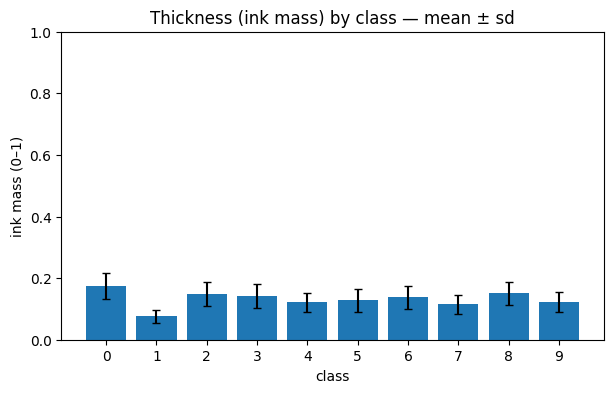

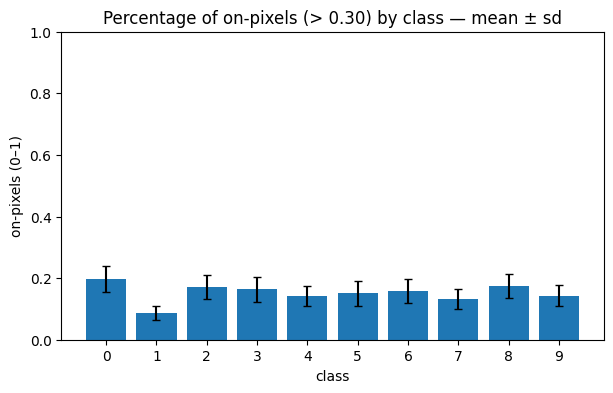

C:\Users\ricar\AppData\Local\Temp\ipykernel_9484\171648464.py:52: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[str(k) for k in range(10)], showmeans=True)


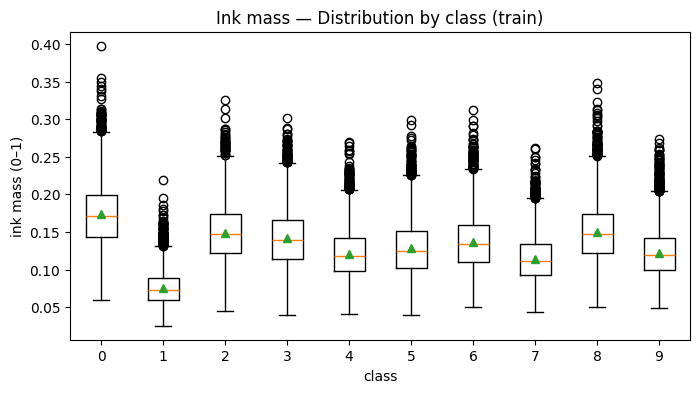

In [22]:
X = X_train   
Y = y_train

# 1) normalize to [0,1] if it is still in [0,255]
Xf = X.float()
if Xf.max() > 1.5:
    Xf = Xf / 255.0

H, W = Xf.shape[1], Xf.shape[2]
area = float(H * W)

# 2) thickness proxies
ink_mass   = Xf.sum(dim=(1,2)) / area          # average intensity per image ∈ [0,1]
thr        = 0.30                               # threshold in normalized space
on_pixels  = (Xf > thr).float().mean(dim=(1,2)) # fraction of "active" pixels ∈ [0,1]

# 3) aggregation by class
rows = []
for k in range(10):
    idx = (Y == k)
    m_mass = float(ink_mass[idx].mean())
    s_mass = float(ink_mass[idx].std(unbiased=True))
    m_on   = float(on_pixels[idx].mean())
    s_on   = float(on_pixels[idx].std(unbiased=True))
    rows.append([k, m_mass, s_mass, m_on, s_on])

df_thickness = pd.DataFrame(rows, columns=["classe","ink_mass_mean","ink_mass_std","onpx_mean","onpx_std"])
print(df_thickness.round(4))

# 4) Graphs — bar charts with error bars
x = np.arange(10)

plt.figure(figsize=(7,4))
plt.bar(x, df_thickness["ink_mass_mean"], yerr=df_thickness["ink_mass_std"], capsize=3)
plt.title("Thickness (ink mass) by class — mean ± sd")
plt.xlabel("class"); plt.ylabel("ink mass (0–1)")
plt.xticks(x)
plt.ylim(0, 1)
plt.show()

plt.figure(figsize=(7,4))
plt.bar(x, df_thickness["onpx_mean"], yerr=df_thickness["onpx_std"], capsize=3)
plt.title(f"Percentage of on-pixels (> {thr:.2f}) by class — mean ± sd")
plt.xlabel("class"); plt.ylabel("on-pixels (0–1)")
plt.xticks(x)
plt.ylim(0, 1)
plt.show()

# 5) boxplots to see the within-class dispersion
plt.figure(figsize=(8,4))
data = [ink_mass[(Y==k)].cpu().numpy() for k in range(10)]
plt.boxplot(data, labels=[str(k) for k in range(10)], showmeans=True)
plt.title("Ink mass — Distribution by class (train)")
plt.xlabel("class"); plt.ylabel("ink mass (0–1)")
plt.show()

**Stroke thickness & active pixels (train)**  
- Class **0** uses the most ink on average (0.173) , followed by **8**  (0.150) and **2** (0.149).  
- Class **1** is the thinnest (**~0.076**), well below all others.  
- The % of active pixels (>0.30) mirrors the same ordering (0/8 > 2/3 > 6/5/9/4/7 > 1), i.e., both proxies are strongly aligned.  
- Within-class variability (std) is largest for **0/2/3/6/8** (0.037–0.042) and smallest for **1** (~0.022).  

 - MNIST thickness is class-dependent (0/8 thicker, 1 thinner). This may bias simple binarization/thresholding; prefer per-image normalization. Worth checking if misclassifications concentrate on thin vs thick digits.


## 5.3 Intra-class variability

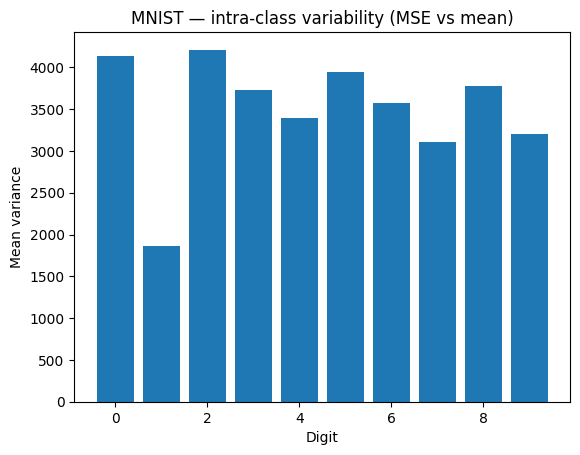

In [23]:
intra_var = []
for k in range(10):
    imgs = X_train[y_train==k].float()                    # [Nk,28,28]
    mu = imgs.mean(0, keepdim=True)
    v = (imgs - mu).pow(2).mean().item()                  # MSE relativa à média
    intra_var.append(v)

plt.bar(range(10), intra_var)
plt.title("MNIST — intra-class variability (MSE vs mean)")
plt.xlabel("Digit") 
plt.ylabel("Mean variance")
plt.show()


**MNIST — intra-class variability (MSE vs class mean)**
- Each bar = average pixel MSE of images in a class to that class’s mean image → **higher = more shape variability**.
- Lowest variability: **1** (thin, consistent).  
- Higher variability: **0, 2, 3, 5, 8** (loops/curves and multiple writing styles). Others are mid-range.
- **Implications:** expect more confusions on high-variability digits; include mild augmentation (±10° rotation, ±2 px shifts) and report **per-class accuracy**.


## 5.4 Class similarity (cosine between mean images)

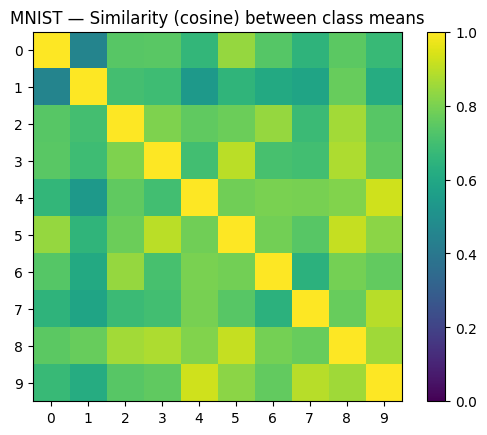

In [24]:
means = [X_train[y_train==k].float().mean(0).view(-1) for k in range(10)]
M = torch.stack(means)                                    # [10, 784]
M = M / (M.norm(dim=1, keepdim=True) + 1e-8)             # normaliza
sim = (M @ M.T).numpy()                                   # cosseno

plt.imshow(sim, vmin=0, vmax=1)
plt.colorbar()
plt.xticks(range(10))
plt.yticks(range(10))
plt.title("MNIST — Similarity (cosine) between class means")
plt.show()


**MNIST — cosine similarity between class means (how to read)**
- Each cell = cosine similarity between the **average image** of two digits (1.0 = identical).
- Off-diagonal bright cells indicate **look-alike classes** → potential confusions.

**Observations**
- Highest off-diagonal similarities appear around pairs like **4↔9**, **3↔5**, **3↔8**, **5↔8**, **2↔3**.
- Diagonal is ≈1 (sanity check); borders are lower, indicating distinct classes overall.

**Implications**
- Expect more errors on the pairs above; report **per-class accuracy** and show a **confusion matrix**.
- Light augmentation (±2 px shifts, ±10° rotations) can help separate these similar patterns.


## 5.5 Visual confusability 

In [33]:

# 1) Ensure we have class means as a single float tensor: [10, 28, 28] 
if "means" not in globals():
    # X_train: [N, 28, 28] or [N, 1, 28, 28], y_train: [N]
    means = []
    for k in range(10):
        imgs_k = X_train[y_train == k].float()
        if imgs_k.ndim == 4 and imgs_k.shape[1] == 1:
            imgs_k = imgs_k.squeeze(1)       # [n_k, 28, 28]
        mu_k = imgs_k.mean(0)                 # [28, 28]
        means.append(mu_k)
    means = torch.stack(means, dim=0)         # [10, 28, 28]
else:
    # If `means` already exists, force it to the correct tensor shape
    if isinstance(means, list):
        means = [m if isinstance(m, torch.Tensor) else torch.tensor(m) for m in means]
        means = torch.stack(means, dim=0)     # [10, H, W] (expects consistent shapes)
    elif not isinstance(means, torch.Tensor):
        means = torch.tensor(means)

    # Drop singleton channel if present: [10,1,28,28] -> [10,28,28]
    if means.ndim == 4 and means.shape[1] == 1:
        means = means.squeeze(1)

    # Final assert/fix to float
    means = means.float()

# Flatten and L2-normalize means for cosine similarity 
# Use .flatten(1) (safer than .view for non-contiguous) -> [10, 28*28]
M = means.flatten(1)
M = F.normalize(M, p=2, dim=1, eps=1e-8)      # row-wise L2
sim = (M @ M.T).clamp(-1, 1).detach().cpu().numpy()  # [10,10]

#  2) Intra-class variability proxy: MSE vs class mean 
if "intra_var" in globals() and isinstance(intra_var, (list, np.ndarray)) and len(intra_var) == 10:
    iv = np.asarray(intra_var, dtype=float)
else:
    iv = []
    for k in range(10):
        imgs = X_train[y_train == k].float()
        if imgs.ndim == 4 and imgs.shape[1] == 1:
            imgs = imgs.squeeze(1)            # [n_k, 28, 28]
        mu = imgs.mean(0, keepdim=True)       # [1, 28, 28]
        v = (imgs - mu).pow(2).mean()         # scalar
        iv.append(float(v.item()))
    iv = np.array(iv, dtype=float)

# Normalize variability to [0,1] (guarding division by zero)
den = (iv.max() - iv.min())
iv_norm = (iv - iv.min()) / (den + 1e-8)

# 3) Rank likely-confusable pairs (similarity × avg variability) 
pairs = []
for i in range(10):
    for j in range(i+1, 10):
        score = float(sim[i, j]) * (0.5 * (iv_norm[i] + iv_norm[j]))
        pairs.append((score, float(sim[i, j]), float(iv_norm[i]), float(iv_norm[j]), i, j))

pairs_sorted = sorted(pairs, key=lambda x: x[0], reverse=True)

# Print top-k pairs with scores
top_k = 6
print("Top likely-confusable pairs (by similarity × variability):")
print("(pair)  combined  cosine   iv_i   iv_j")
for t in pairs_sorted[:top_k]:
    score, cos, ivi, ivj, a, b = t
    print(f"({a},{b})  {score:7.4f}   {cos:6.3f}  {ivi:5.3f}  {ivj:5.3f}")

#  4) Visual sanity-check: show a few samples for the top pairs 
def show_pair_examples(k_pairs=4, samples_per_class=4, seed=42):
    rng = np.random.default_rng(seed)
    for idx in range(min(k_pairs, len(pairs_sorted))):
        _, cos, _, _, a, b = pairs_sorted[idx]
        xa = X_train[y_train == a]
        xb = X_train[y_train == b]

        # Squeeze channel if present for plotting
        if xa.ndim == 4 and xa.shape[1] == 1:
            xa = xa.squeeze(1)
        if xb.ndim == 4 and xb.shape[1] == 1:
            xb = xb.squeeze(1)

        na = len(xa); nb = len(xb)
        sa = min(samples_per_class, na)
        sb = min(samples_per_class, nb)
        ia = rng.choice(na, size=sa, replace=False)
        ib = rng.choice(nb, size=sb, replace=False)

        fig, axes = plt.subplots(2, samples_per_class, figsize=(2.2*samples_per_class, 4.4))
        # If classes have fewer samples than requested, fill remaining slots blank
        for c in range(samples_per_class):
            ax_top = axes[0, c]
            ax_bot = axes[1, c]

            if c < sa:
                img_a = xa[ia[c]].detach().cpu().numpy()
                ax_top.imshow(np.squeeze(img_a), cmap="gray", vmin=0, vmax=255 if img_a.max() > 1.5 else 1.0)
                ax_top.set_title(f"{a}")
            else:
                ax_top.axis("off")

            if c < sb:
                img_b = xb[ib[c]].detach().cpu().numpy()
                ax_bot.imshow(np.squeeze(img_b), cmap="gray", vmin=0, vmax=255 if img_b.max() > 1.5 else 1.0)
                ax_bot.set_title(f"{b}")
            else:
                ax_bot.axis("off")

            ax_top_


Top likely-confusable pairs (by similarity × variability):
(pair)  combined  cosine   iv_i   iv_j
(0,5)   0.7827    0.843  0.970  0.888
(2,8)   0.7816    0.860  1.000  0.817
(5,8)   0.7777    0.912  0.888  0.817
(3,5)   0.7554    0.898  0.794  0.888
(0,2)   0.7308    0.742  0.970  1.000
(2,5)   0.7303    0.774  1.000  0.888


Top likely-confusable pairs (by similarity × variability):
(pair)  combined  cosine   iv_i   iv_j
(0,5)   0.7827    0.843  0.970  0.888
(2,8)   0.7816    0.860  1.000  0.817
(5,8)   0.7777    0.912  0.888  0.817
(3,5)   0.7554    0.898  0.794  0.888
(0,2)   0.7308    0.742  0.970  1.000
(2,5)   0.7303    0.774  1.000  0.888


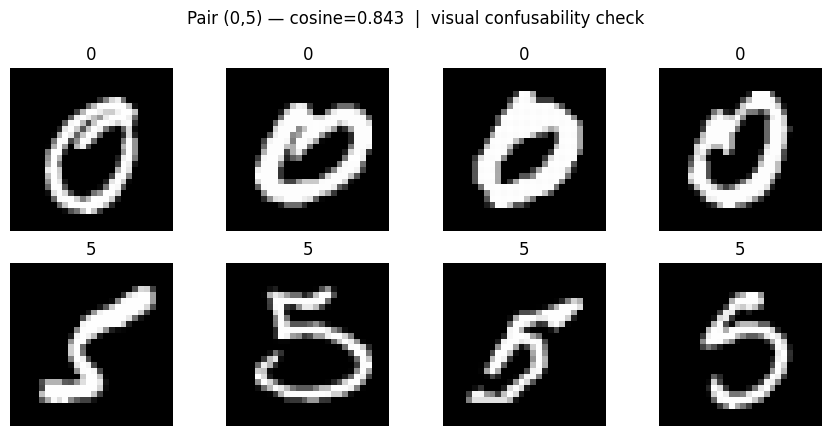

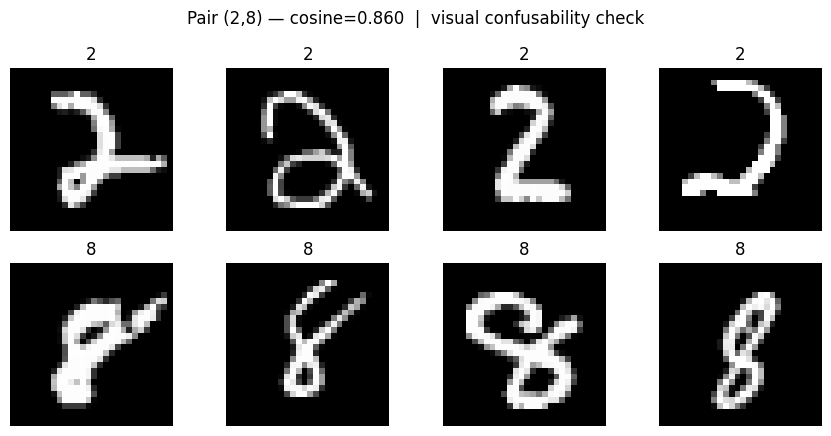

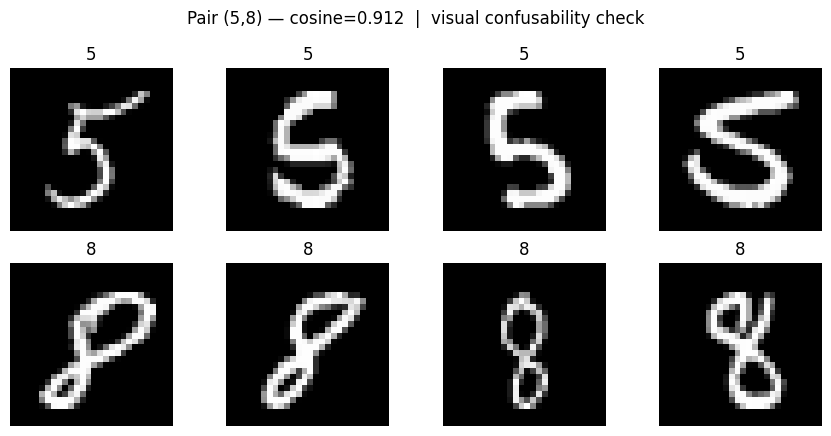

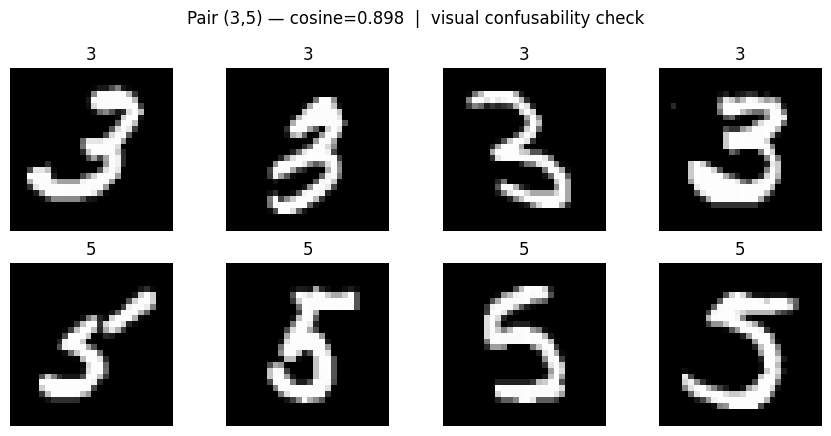

In [34]:
# 1) Ensure we have class means [10, 28, 28]
if "means" not in globals():
    means = [X_train[y_train == k].float().mean(0) for k in range(10)]  # [28,28] each
    means = [m if m.ndim == 2 else m.squeeze() for m in means]
    means = torch.stack(means, dim=0)  # [10,28,28]

# Flatten and L2-normalize means for cosine similarity
M = means.view(10, -1).float()
M = M / (M.norm(dim=1, keepdim=True) + 1e-8)
sim = (M @ M.T).cpu().numpy()  # [10,10], cosine ∈ [-1,1]

# 2) (Optional) intra-class variability proxy: MSE vs class mean
# If `intra_var` exists from your previous cell, it will be used. Otherwise compute a quick version.
if "intra_var" in globals() and isinstance(intra_var, (list, np.ndarray)) and len(intra_var) == 10:
    iv = np.asarray(intra_var, dtype=float)  # higher = more variable shapes
else:
    iv = []
    for k in range(10):
        imgs = X_train[y_train == k].float()
        mu = imgs.mean(0, keepdim=True)
        v = (imgs - mu).pow(2).mean()  # scalar MSE vs mean
        iv.append(float(v.item()))
    iv = np.array(iv)

# Normalize variability to [0,1] for a combined score
iv_norm = (iv - iv.min()) / (iv.max() - iv.min() + 1e-8)

# 3) Build a ranked list of likely-confusable pairs
pairs = []
for i in range(10):
    for j in range(i+1, 10):
        # combined score: high cosine similarity + average variability
        score = sim[i, j] * (0.5 * (iv_norm[i] + iv_norm[j]))
        pairs.append((score, sim[i, j], iv_norm[i], iv_norm[j], i, j))

pairs_sorted = sorted(pairs, key=lambda x: x[0], reverse=True)

# Print top-k pairs with scores
top_k = 6
print("Top likely-confusable pairs (by similarity × variability):")
print("(pair)  combined  cosine   iv_i   iv_j")
for t in pairs_sorted[:top_k]:
    score, cos, ivi, ivj, a, b = t
    print(f"({a},{b})  {score:7.4f}   {cos:6.3f}  {ivi:5.3f}  {ivj:5.3f}")

# 4) Visual sanity-check: show a few samples for the top pairs
def show_pair_examples(k_pairs=4, samples_per_class=4):
    rng = np.random.default_rng(42)
    for idx in range(min(k_pairs, len(pairs_sorted))):
        _, cos, _, _, a, b = pairs_sorted[idx]
        xa = X_train[y_train == a]
        xb = X_train[y_train == b]
        ia = rng.choice(len(xa), size=min(samples_per_class, len(xa)), replace=False)
        ib = rng.choice(len(xb), size=min(samples_per_class, len(xb)), replace=False)
        fig, axes = plt.subplots(2, samples_per_class, figsize=(2.2*samples_per_class, 4.4))
        for c in range(samples_per_class):
            axes[0, c].imshow(xa[ia[c]].cpu().numpy(), cmap="gray", vmin=0, vmax=255)
            axes[0, c].set_title(f"{a}")
            axes[0, c].axis("off")
            axes[1, c].imshow(xb[ib[c]].cpu().numpy(), cmap="gray", vmin=0, vmax=255)
            axes[1, c].set_title(f"{b}")
            axes[1, c].axis("off")
        fig.suptitle(f"Pair ({a},{b}) — cosine={cos:.3f}  |  visual confusability check")
        plt.tight_layout()
        plt.show()

show_pair_examples(k_pairs=4, samples_per_class=4)


## 5.6 “Ink” by image (percentage of pixels > 0) + visual outliers

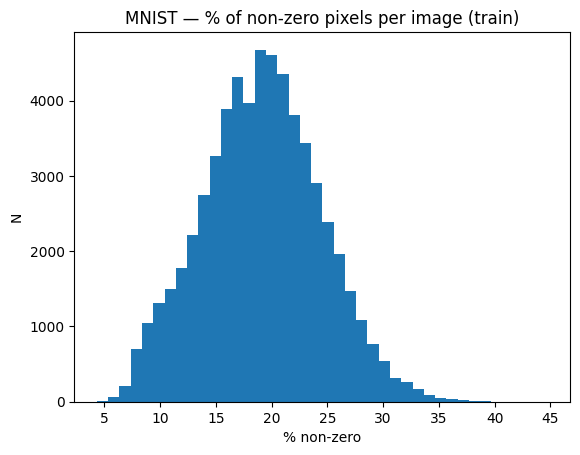

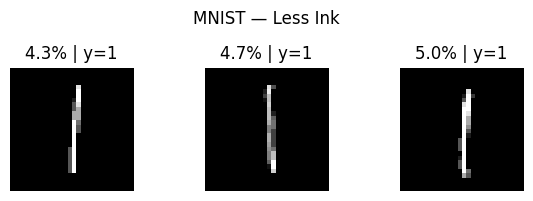

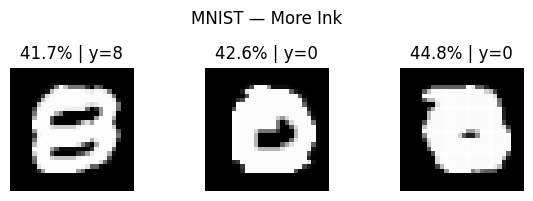

In [35]:
ink_per_img = (X_train > 0).float().mean(dim=(1,2)).numpy() * 100

plt.figure()
plt.hist(ink_per_img, bins=40)
plt.title("MNIST — % of non-zero pixels per image (train)")
plt.xlabel("% non-zero"); plt.ylabel("N") 
plt.show()

# Mostrar os 3 com menos e 3 com mais "ink"
idx_small = np.argsort(ink_per_img)[:3]
idx_big   = np.argsort(ink_per_img)[-3:]
for idxs, ttl in [(idx_small,"Less Ink"), (idx_big,"More Ink")]:
    fig, axes = plt.subplots(1,3, figsize=(6,2))
    for ax,i in zip(axes, idxs):
        ax.imshow(X_train[i].numpy(), cmap="gray", vmin=0, vmax=255)
        ax.set_title(f"{ink_per_img[i]:.1f}% | y={int(y_train[i])}")
        ax.axis("off")
    fig.suptitle(f"MNIST — {ttl}") 
    plt.tight_layout(); plt.show()

**MNIST — % of non-zero pixels per image (train)**
- Distribution is **unimodal**, centered around **~20%** active pixels (most images are sparse).
- **Low-ink tail (~5–10%)**: mainly thin digits (e.g., **1/7**).  
  **High-ink tail (~30–45%)**: looped/thick digits (e.g., **0/8/9**).
- Takeaways: report **per-class metrics** (coverage varies by digit); keep **Dropout modest** for thin digits; light **shift/rotation augmentation** helps without inflating “ink”.


# 6. Distribution Stability and Drift

## 6.1 Mean/Std shift maps (train vs test)

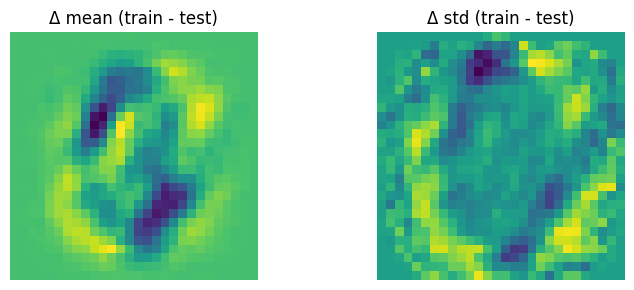

MMD²: 0.008641242980957031


In [36]:
sys.path.append("/mnt/data") 
drift = train_test_drift(X_train, X_test)  # mostra mapas e retorna mmd2
print("MMD²:", drift["mmd2"])

**Train–test drift (Δ mean/std + MMD²)**
- Heatmaps show only **subtle** differences in where strokes appear; borders stay dark → **no structural shift**.
- **MMD² = 0.0086** (RBF-kernel, lower is better) is **very small**, indicating **negligible covariate drift** between train and test.
- Takeaway: the standard MNIST normalization is valid; no domain-adaptation or rebalancing is required. Proceed to modeling.


## 6.2 Maximum Mean Discrepancy (MMD²)

In [37]:
m = 0.008641242980957031  # your MMD^2
label = "no drift" if m < 0.02 else ("small drift" if m < 0.05 else "moderate drift")
print(f"MMD^2={m:.4f} → {label}")


MMD^2=0.0086 → no drift


MMD² = **0.0086** → **no drift**. Train and test come from the same distribution; the standard MNIST normalization is valid and no domain adaptation/rebalancing is required before modeling.

## 6.3 Pixel-wise Mean Shift (μ_test − μ_train)

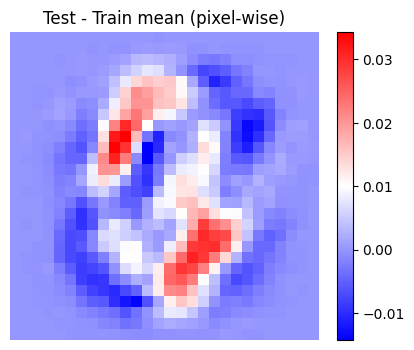

In [38]:
tr = datasets.MNIST("./data", train=True,  download=True).data.float()/255.0
te = datasets.MNIST("./data", train=False, download=True).data.float()/255.0
diff = (te.mean(0) - tr.mean(0)).numpy()  # [28,28]
plt.figure(figsize=(5,4))
plt.imshow(diff, cmap="bwr") 
plt.colorbar() 
plt.title("Test - Train mean (pixel-wise)")
plt.axis("off")
plt.show()

- Differences are small (≈±0.03) and concentrated around digit strokes, suggesting negligible covariate shift between train and test

## 6.4 Per-class check

In [39]:
tr = datasets.MNIST("./data", train=True ).data.float()/255
te = datasets.MNIST("./data", train=False).data.float()/255
d  = te.mean(0) - tr.mean(0)
print(
    f"max|Δ|={float(d.abs().max()):.4f}, "
    f"mean|Δ|={float(d.abs().mean()):.5f}"
)


max|Δ|=0.0343, mean|Δ|=0.00435


****
max_delta  = 0.0343   # max |μ_test - μ_train| per pixel (images normalized to [0,1])
mean_delta = 0.00435  # mean |μ_test - μ_train| per pixel

### Pixel-wise mean shift (test vs. train)

- Metrics on normalized images ([0,1]): **max|Δ| = {max_delta:.4f}**, **mean|Δ| = {mean_delta:.5f}**.  
- Interpretation: largest average per-pixel difference ≈ **{max_delta*100:.1f}%** of full intensity; average difference ≈ **{mean_delta*100:.1f}%**.  
- Pattern: shift is **localized on digit strokes** (background ≈ 0), not a uniform/global change.  
- **Takeways** No material covariate drift between splits. Keep the **same MNIST normalization** for train/test; **no reweighting/domain adaptation** needed.


# 7. Data Representation and Clustering

## 7.1 t-SNE (N≈2000) – raw pixels

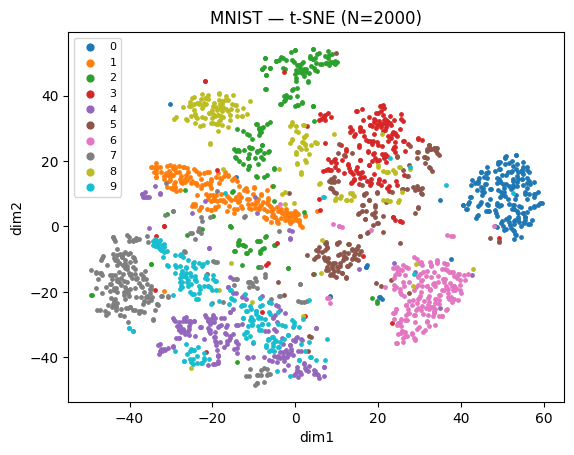

In [40]:
from sklearn.manifold import TSNE

N = 2000
X = X_train[:N].reshape(N, -1).float().numpy()/255.0
y = y_train[:N].numpy()

X2 = TSNE(n_components=2, init='pca', random_state=42, perplexity=30).fit_transform(X)

plt.figure()
for k in range(10):
    m = (y==k)
    plt.scatter(X2[m,0], X2[m,1], s=6, label=str(k))
plt.title("MNIST — t-SNE (N=2000)")
plt.xlabel("dim1")
plt.ylabel("dim2")
plt.legend(markerscale=2, fontsize=8) 
plt.show()


**MNIST — t-SNE (N=2000): quick read**
- Clear **clusters** for most digits; **0/2/9** are the most separated.
- Visible overlaps where shapes are similar: **4↔9**, **3↔5↔8**, **2↔3**.
- Reminder: t-SNE preserves **local neighborhoods** only; **global distances/cluster sizes aren’t comparable** and the layout changes with perplexity/seed.
- This plot uses **raw pixels**; separation typically improves if we run t-SNE on **MLP embeddings** (penultimate layer).
